<a href="https://colab.research.google.com/github/KhoirotunNisa25/PCVK_Ganjil_2025/blob/main/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modul 3: Operasi Dasar Citra

## Praktikum D1: Operasi Citra Sederhana

### Langkah 2: Akses folder images

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np

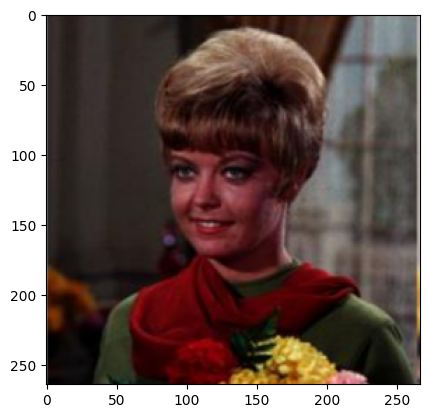

In [3]:
img = cv.imread('/content/drive/MyDrive/PCVK/Images/female.tiff')
plt.imshow(cv.cvtColor(img,cv.COLOR_BGR2RGB))

### Langkah 3: Melakukan transformasi linier brightness

   Mengubah tingkat kecerahan citra   
--------------------------------------
Masukkan nilai kecerahan:   50


/tmp/ipython-input-995373263.py:15: RuntimeWarning: overflow encountered in scalar add
  brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)


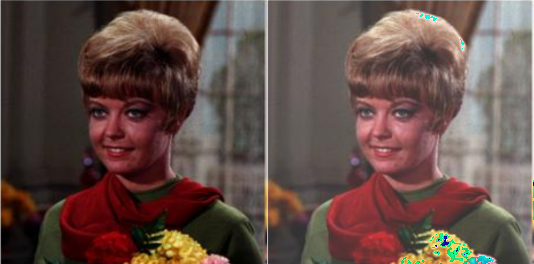

In [4]:
print('   Mengubah tingkat kecerahan citra   ')
print('--------------------------------------')
try:
  brightness = int(input('Masukkan nilai kecerahan:   '))
except ValueError:
  print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK/Images/female.tiff')
brightness_image = np.zeros(original.shape, original.dtype)

#akses per piksel
for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    for c in range(original.shape[2]):
      brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

#cara simpel tanpa for loop
#brightness_image = cv.convertScaleAbs(original, beta-brightness)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

## Tugas Praktikum D3

### 1. Implementasikan invers citra

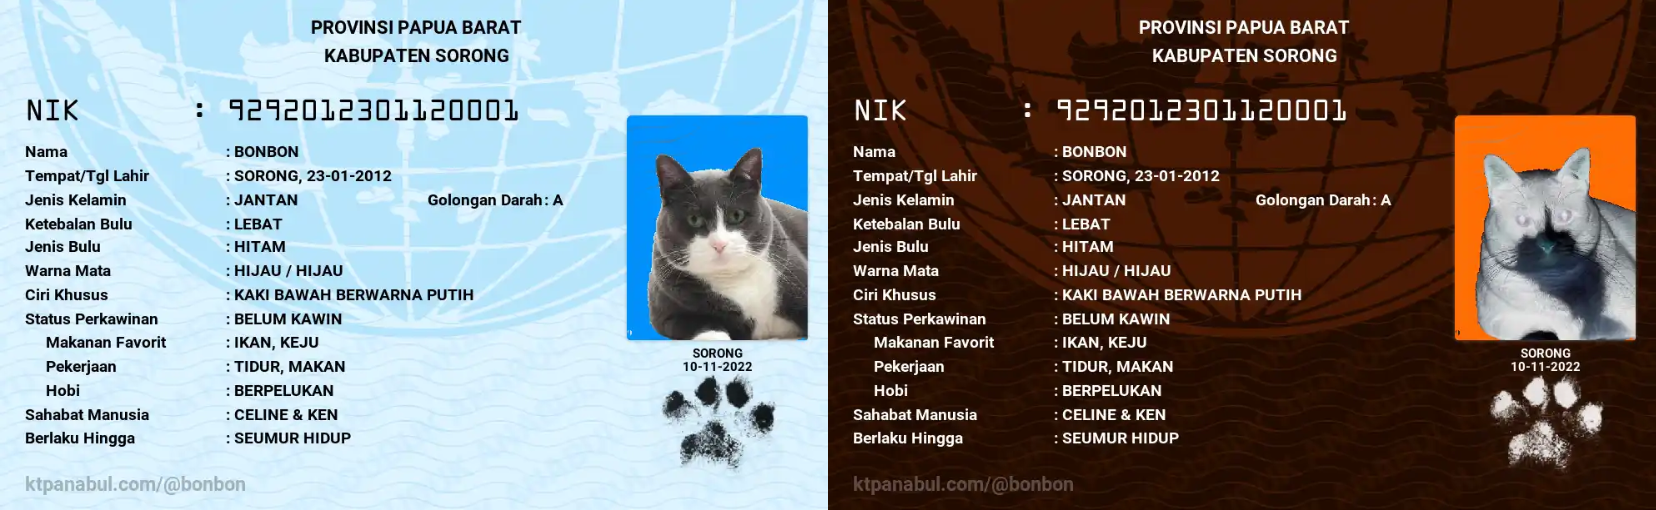

In [5]:
original = cv.imread('/content/drive/MyDrive/PCVK/Images/KTP.png')
inverted_image = np.zeros(original.shape, original.dtype)

#akses per piksel
for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    for c in range(original.shape[2]):
      inverted_image[y,x,c] = 255 - original[y,x,c]

final_frame = cv.hconcat((original, inverted_image))
cv2_imshow(final_frame)

### 2. Implementasikan transformasi contrast
(g(x,y)=α⋅f(x,y)+β)

   Mengubah kontras dan tingkat kecerahan citra   
--------------------------------------------------
Masukkan tingkat kecerahan [-255 sampai 255]: 50
Masukkan nilai kontras [1.0 - 3.0]: 2


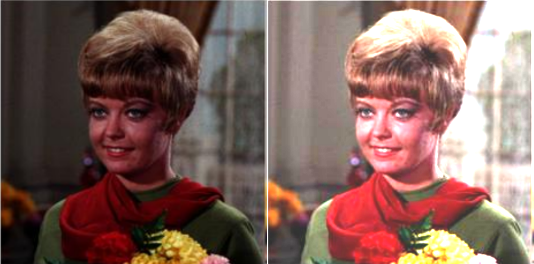

In [6]:
print('   Mengubah kontras dan tingkat kecerahan citra   ')
print('--------------------------------------------------')

# input dari user
try:
  brightness = int(input('Masukkan tingkat kecerahan [-255 sampai 255]: '))
  contrast = float(input('Masukkan nilai kontras [1.0 - 3.0]: '))
except ValueError:
  print('Error, input tidak valid')
  brightness, contrast = 0, 1.0

original = cv.imread('/content/drive/MyDrive/PCVK/Images/female.tiff')
result = np.zeros(original.shape, original.dtype)

# akses per piksel
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            # g(x,y) = contrast * f(x,y) + brightness
            result[y,x,c] = np.clip(contrast * original[y,x,c] + brightness, 0, 255)

# cara simpel tanpa loop
# result = cv.convertScaleAbs(original, alpha=contrast, beta=brightness)

# gabungkan hasil
final_frame = cv.hconcat((original, result))
cv2_imshow(final_frame)


### 3. Implementasikan transformasi logarithmic brightness

   Mengubah tingkat kecerahan citra dengan Transformasi Log   
--------------------------------------------------------------
Masukkan nilai kecerahan: 50


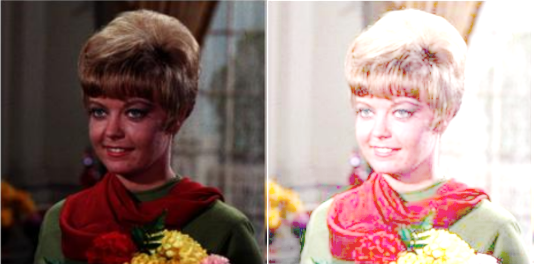

In [7]:
print('   Mengubah tingkat kecerahan citra dengan Transformasi Log   ')
print('--------------------------------------------------------------')

try:
  brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
  print('Error, input tidak valid')

# load gambar
original = cv.imread('/content/drive/MyDrive/PCVK/Images/female.tiff')

# konversi ke float agar log tidak error
img_float = original.astype(float)

# konstanta c
c = 255 / np.log(1 + np.max(img_float))

# transformasi log + brightness
log_image = c * np.log(1 + img_float) + brightness
log_image = np.clip(log_image, 0, 255)
log_image = np.uint8(log_image)

# gabungkan original dan hasil
final_frame = cv.hconcat((original, log_image))
cv2_imshow(final_frame)


### 4. Implementasi transformasi grayscale

/tmp/ipython-input-2953044484.py:9: RuntimeWarning: overflow encountered in scalar add
  avg_gray[y, x] = int((R + G + B) / 3)


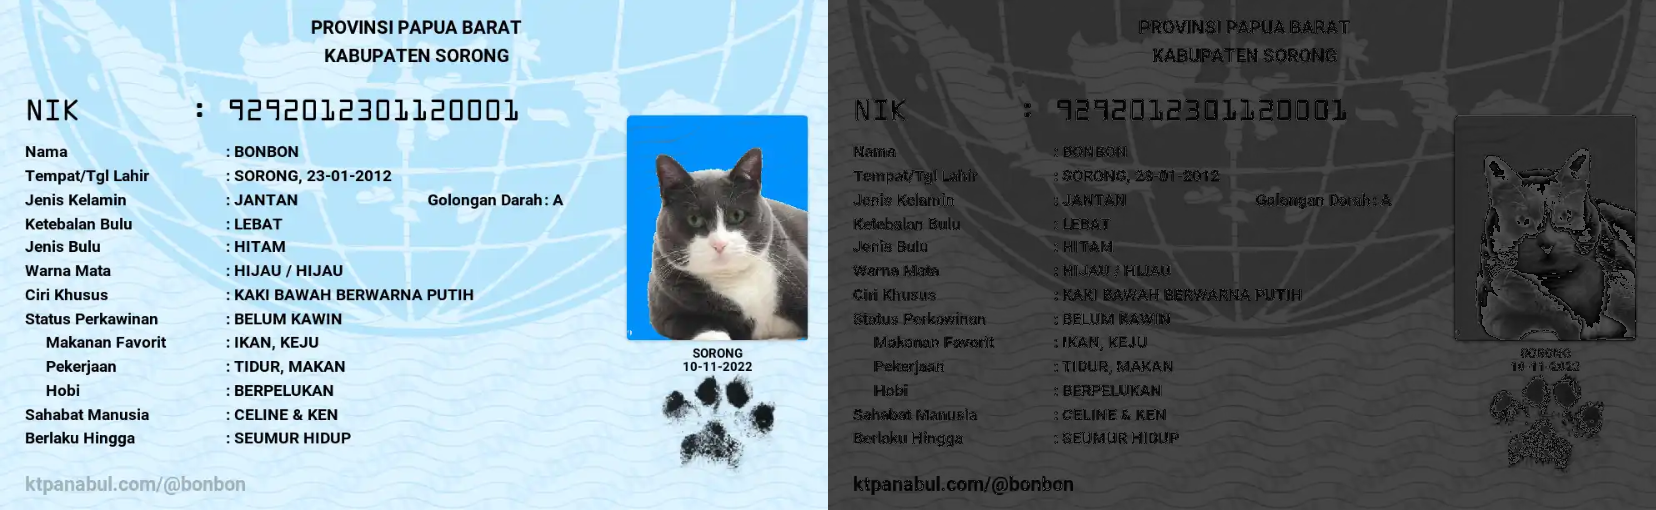

In [8]:
# Metode Averaging

original = cv.imread('/content/drive/MyDrive/PCVK/Images/KTP.png')

avg_gray = np.zeros(original.shape[:2], dtype=np.uint8)
for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    R, G, B = original[y, x][2], original[y, x][1], original[y, x][0]
    avg_gray[y, x] = int((R + G + B) / 3)

final_frame = cv.hconcat([original, cv.cvtColor(avg_gray, cv.COLOR_GRAY2BGR)])
cv2_imshow(final_frame)

/tmp/ipython-input-2108898255.py:6: RuntimeWarning: overflow encountered in scalar add
  lightness_gray[y, x] = int((max(R, G, B) + min(R, G, B)) / 2)


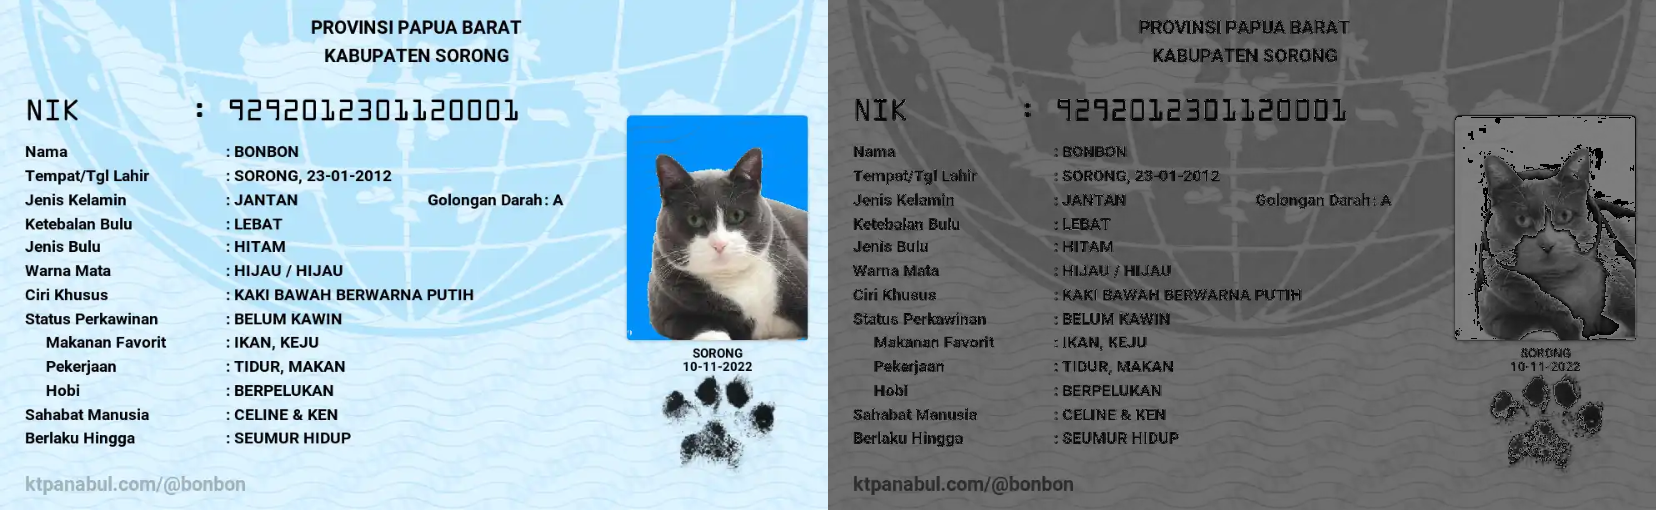

In [9]:
# Lightness
lightness_gray = np.zeros(original.shape[:2], dtype=np.uint8)
for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    R, G, B = original[y, x][2], original[y, x][1], original[y, x][0]
    lightness_gray[y, x] = int((max(R, G, B) + min(R, G, B)) / 2)

final_frame = cv.hconcat([original, cv.cvtColor(lightness_gray, cv.COLOR_GRAY2BGR)])
cv2_imshow(final_frame)


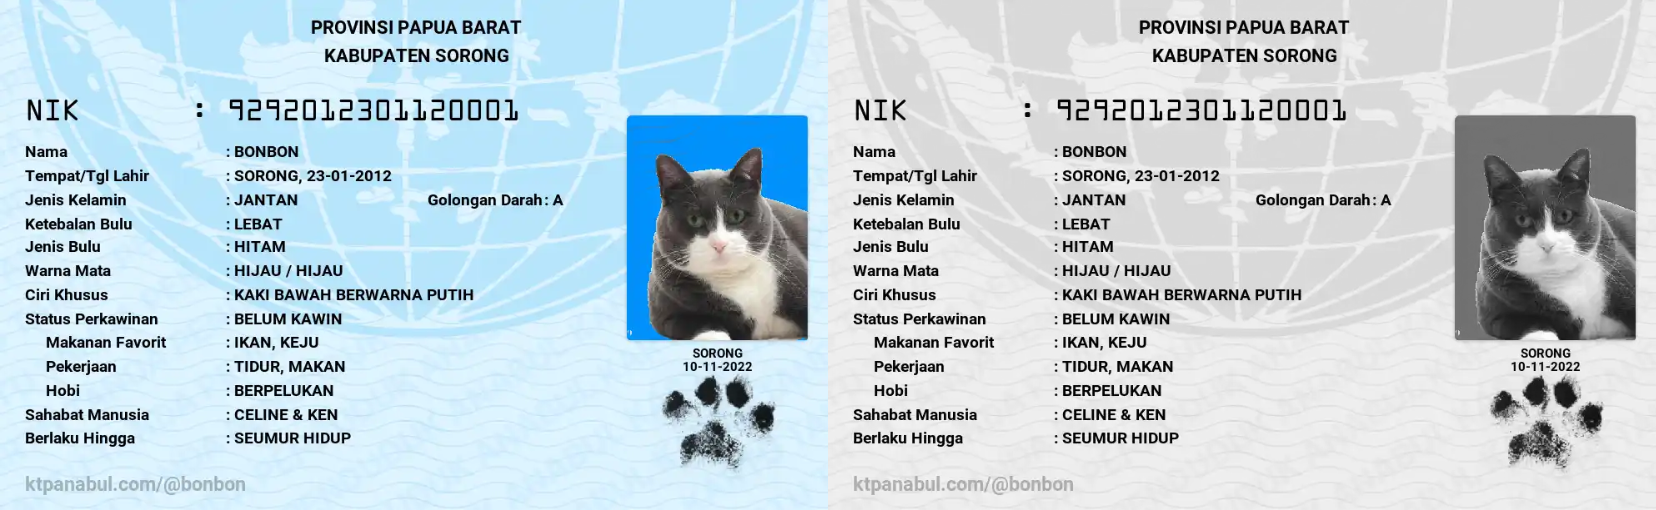

In [10]:
# Luminance
luminance_gray = np.zeros(original.shape[:2], dtype=np.uint8)
for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    R, G, B = original[y, x][2], original[y, x][1], original[y, x][0]
    luminance_gray[y, x] = int(0.299*R + 0.587*G + 0.114*B)

final_frame = cv.hconcat([original, cv.cvtColor(luminance_gray, cv.COLOR_GRAY2BGR)])
cv2_imshow(final_frame)


### 5. Simpan warna tertentu, dan ubah yang lain menjadi grayscale

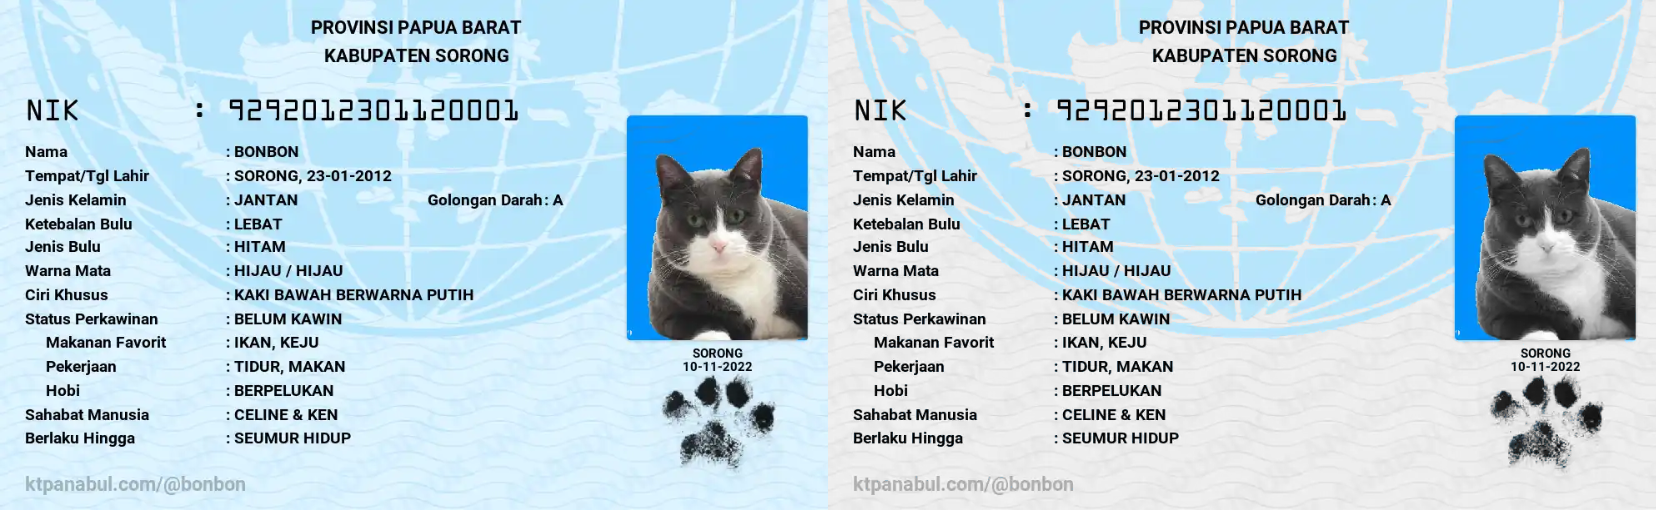

In [11]:
original = cv.imread('/content/drive/MyDrive/PCVK/Images/KTP.png')

# Konversi ke HSV
hsv = cv.cvtColor(original, cv.COLOR_BGR2HSV)

# Tentukan rentang warna biru (dalam HSV)
lower_blue = np.array([90, 50, 50])   # batas bawah
upper_blue = np.array([130, 255, 255]) # batas atas

# Mask untuk warna biru
mask = cv.inRange(hsv, lower_blue, upper_blue)

# Buat versi grayscale dari gambar
gray = cv.cvtColor(original, cv.COLOR_BGR2GRAY)
gray_bgr = cv.cvtColor(gray, cv.COLOR_GRAY2BGR)

# Kombinasikan: warna biru tetap, lainnya jadi grayscale
result = np.where(mask[:, :, None] != 0, original, gray_bgr)

# Gabungkan hasil (original vs hasil selektif)
final_frame = cv.hconcat([original, result])
cv2_imshow(final_frame)


## Praktikum D2: Operasi Aritmatika dan Logika

### Langkah 1: Buat Gamma Correction sesuai dengan petunjuk

   Gamma Correction pada citra   
---------------------------------
Masukkan nilai Gamma: 3


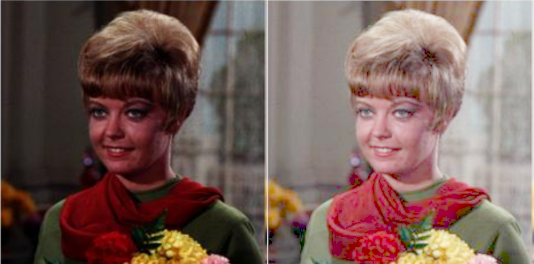

In [12]:
print('   Gamma Correction pada citra   ')
print('---------------------------------')
try:
  gamma = int(input('Masukkan nilai Gamma: '))
except ValueError:
  print('Error, not a number')
  gamma = 1

original = cv.imread('/content/drive/MyDrive/PCVK/Images/female.tiff')

# Normalisasi nilai piksel ke [0,1]
normalized = original / 255.0

# Terapkan gamma correction
gamma_corrected = np.power(normalized, 1.0/gamma)

# Kembalikan ke skala [0,255]
gamma_image = np.uint8(gamma_corrected * 255)

# Tampilkan hasil
final_frame = cv.hconcat((original, gamma_image))
cv2_imshow(final_frame)


### Langkah 2: Buat Simulasi Image Depth

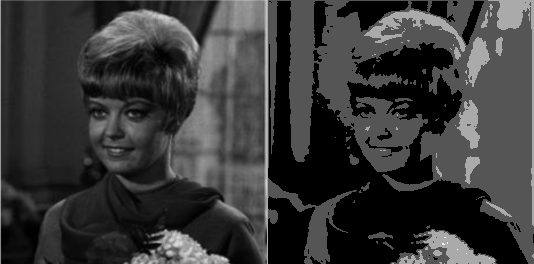

In [13]:
bit_depth = 2

level = 255 / (pow(2, bit_depth) - 1)

original = cv.imread('/content/drive/MyDrive/PCVK/Images/female.tiff', cv.IMREAD_GRAYSCALE)

quantized = np.uint8((original / level).round() * level)

# Tampilkan hasil
final_frame = cv.hconcat([original, quantized])
cv2_imshow(final_frame)

### Langkah 3: Buat Modul Average Denoising

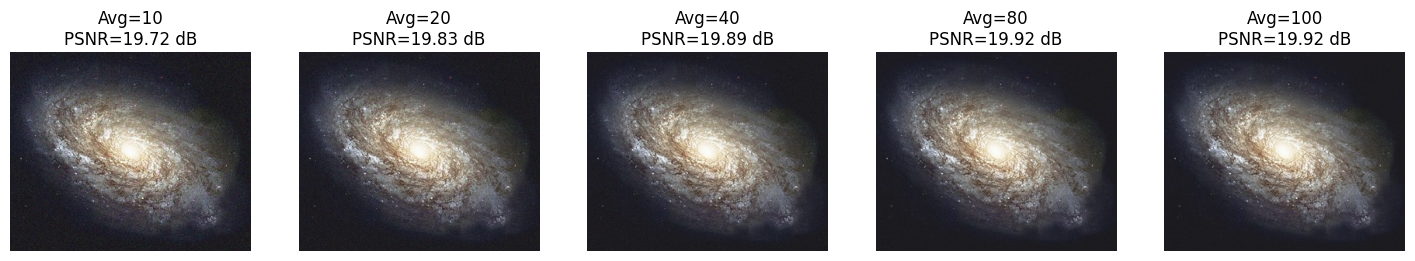

In [14]:
import glob

# Citra asli
original = cv.imread('/content/drive/MyDrive/PCVK/Images/galaxy.jpg')

# Semua citra noisy dari folder
cv_img = []
for img in glob.glob('/content/drive/MyDrive/PCVK/Images/noises/*.jpg'):
    n = cv.imread(img)
    cv_img.append(n)

cv_img = np.array(cv_img)

# Fungsi MSE
def mse(img1, img2):
    return np.mean((img1.astype("float") - img2.astype("float")) ** 2)

# Fungsi PSNR
def psnr(img1, img2):
    m = mse(img1, img2)
    if m == 0:  # sama persis
        return 100
    return 10 * np.log10((255.0 ** 2) / m)

# Jumlah citra untuk di-average
averages = [10, 20, 40, 80, 100]

# Plot hasil
fig, axs = plt.subplots(1, len(averages), figsize=(18,5))
for i, num in enumerate(averages):
    subset = cv_img[:num]
    avg_img = np.mean(subset, axis=0).astype(np.uint8)
    score = psnr(original, avg_img)

    axs[i].imshow(cv.cvtColor(avg_img, cv.COLOR_BGR2RGB))
    axs[i].set_title(f"Avg={num}\nPSNR={score:.2f} dB")
    axs[i].axis('off')

plt.show()

Kesimpulan:
- Semakin banyak citra noisy yang di-average, noise semakin berkurang.
- Nilai PSNR meningkat -> kualitas citra hasil makin mendekati citra asli.
- Setelah titik tertentu (misal >80 gambar), peningkatan PSNR mulai kecil -> artinya efek average saturasi.

### Langkah 4: Buat Image Masking

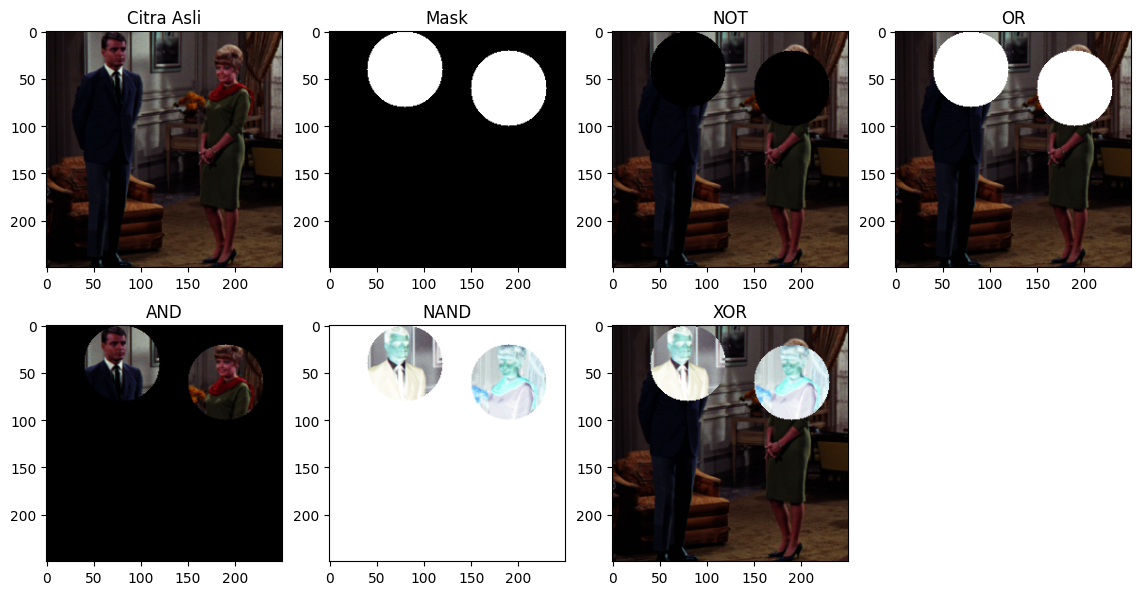

In [15]:
# Baca image asli
img = cv.imread('/content/drive/MyDrive/PCVK/Images/couple.tiff')
img = cv.resize(img, (250, 250))

# Buat mask hitam dengan ukuran sama seperti image
mask = np.zeros((250, 250), dtype="uint8")
cv.circle(mask, (80, 40), 40, 255, -1)
cv.circle(mask, (190, 60), 40, 255, -1)

# Konversi mask jadi 3 channel
mask_3 = cv.merge([mask, mask, mask])

# 1. NOT (komplemen)
not_mask = cv.bitwise_not(mask_3)
not_result = cv.bitwise_and(img, not_mask)

# 2. OR
or_result = cv.bitwise_or(img, mask_3)

# 3. AND
and_result = cv.bitwise_and(img, mask_3)

# 4. NAND (Not AND)
nand_result = cv.bitwise_not(and_result)

# 5. XOR
xor_result = cv.bitwise_xor(img, mask_3)

titles = ['Citra Asli', 'Mask', 'NOT', 'OR', 'AND', 'NAND', 'XOR']
images = [img, mask_3, not_result, or_result, and_result, nand_result, xor_result]

plt.figure(figsize=(14,7))
for i in range(len(images)):
    plt.subplot(2,4,i+1)
    plt.imshow(cv.cvtColor(images[i], cv.COLOR_BGR2RGB))
    plt.title(titles[i])
plt.show()

**Hasil Analisa**
1. NOT:
    - mask awalnya punya lingkaran putih (255) di area tertentu, sisanya hitam (0).
    - Setelah bitwise_not, lingkaran jadi hitam, latar belakang jadi putih.
    - bitwise_and(img, not_mask) -> bagian hitam di mask membuat area tersebut jadi hitam (terpotong), sedangkan bagian putih tetap mempertahankan citra.
    - Hasil: wajah orang jadi hitam (tertutup).
2. OR:
    - OR bekerja dengan aturan: 1 OR 0 = 1, 1 OR 1 = 1
    - Karena mask_3 punya lingkaran putih (255), area lingkaran jadi putih penuh di hasil.
    - Hasil: lingkaran di atas jadi putih polos.
3. AND:
    - AND hanya menyisakan bagian citra di mana mask = putih (255)
    - Area di luar lingkaran (hitam pada mask) jadi 0 (hitam di hasil).
    - Hasil: hanya bagian dalam lingkaran yang terlihat.
4. NAND:
    - AND dulu -> hanya area lingkaran yang terlihat.
    - NOT dari hasil AND -> bagian lingkaran jadi terbalik warnanya (invers), area luar lingkaran jadi putih.
    - Hasil: terlihat seperti efek negatif di lingkaran.
5. XOR:
    - 1 XOR 1 = 0, 1 XOR 0 = 1
    - Jika mask = hitam (0), hasil = sama seperti img.
    - Jika mask = putih (255), nilai piksel di citra diubah (karena beda dengan putih -> jadi “dibalik” warnanya).
    - Hasil: lingkaran tidak jadi putih polos, tapi tampil dengan warna yang kontras/invers dibanding citra asli. Efeknya mirip campuran antara negatif dan potongan, hanya muncul di bagian lingkaran.